<a href="https://colab.research.google.com/github/AlexanderEgorovNRNUMEPHI/AIM-projects/blob/main/ML/Gradient%20boosting/%D0%90%D0%BB%D0%B5%D0%BA%D1%81%D0%B0%D0%BD%D0%B4%D1%80_%D0%95%D0%B3%D0%BE%D1%80%D0%BE%D0%B2_%D0%A2%D1%80%D0%B0%D0%BD%D0%B7%D0%B0%D0%BA%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_log_error
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline

import lightgbm as lgb

pd.options.mode.chained_assignment = None
pd.options.display.max_columns = 999

from feature_tools import *
from general_tools import *




# Финальный пайплайн

Основная идея взята из решения первого места оригинального контеста, но в моей интерпретации.


**Разбиение данных:**

Данные из train  делятся на 2 непересекающихся df, моделируя условия, при которых будет считаться итоговый скор:

TRAIN_WINDOW = 76
OFFSET = 13
TEST_WINDOW = 32

Значения окон я посчитал из условий, что тестовые данные станут train для модели, а итоговое предсказание отстоит от них на офсет и содержит TEST_WINDOW дней. Реальный OFFSET немного больше(16 дней), я изменил его, чтобы не нарушалась размерность двух полученных непересекающихся наборов данных.

**Подготовка фичей:**
Выкидываю все колонки с trafficSource(у меня с ними предсказания хуже)
Агрегацию делаю по следующему правилу: для числовых фичей считаю max, min, sum, mean статистики; для категориальных перевожу их в числовые с помощью LabelEncoder из sklearn и беру самые часто встречающиеся для пользователя. Для дат считаю разницы между событием и первой/последней датой в непересекающихся df, полученных выше; также добавляю количество уникальных сессий для клиента.

**Модель:**

Далее 2 непересекающихся тренировочных df, полученных выше объединяются в 1 обучающий, а 2 непересекающихся тестовых df в один валидационный. Считаются 2 модели: классификация(вернется ли клиент из тренировочного периода в теством) и регрессия(сколько он потратит). Таргет для регрессии делил на 10**6, как в задании. Параметры модели особо не подбирал, взял похожие из обсуждений и немного сам покрутил без optuna.

**Проверка:**
Далее расчитывал predict на валидационном наборе и смотрел результат итоговой метрики, т.е. берется вероятность из модели классификации и умножается на сумму из модели регрессии. Дополнительно сабмитил и смотрел на отложенном контроле. Здесь нет кросвалидации, но проверка идет на "честно построенном и максимально приближенным к реальности" пайплайне, поэтому для оценки моделей я здесь и далее использую метрику на валидационном наборе.
В качестве метрики качества я везде рассматривал msle. Правильнее было бы рассматривать amsle из контеста(я рассматриваю ее отдельно в секции # Работа с целевой метрикой), но мой итоговый паплайн обучался именно с msle и я оставил ее.








In [ ]:
visitor_aggs_train, visitor_aggs_valid, visitor_aggs_test = get_visitor_aggs('C:/Users/egoro/ml_kaggle', from_cache=True, cat_encoding="label")

train_all = visitor_aggs_train.drop(['order'], axis=1)
valid_all = visitor_aggs_valid.drop(['order'], axis=1)

In [ ]:
outliers = get_outliers(train_all)
train_all_no_otliers = train_all.drop(outliers)

X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(train_all_no_otliers, valid_all, only_returned=False)


lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
lgb_tr_ret = lgb.Dataset(X_ret, y_ret/10**6, free_raw_data=False)

params_classification = {
    'objective': 'binary',
    'verbosity': 1,
    'num_threads': 32,
    'num_leaves': 15,
    'learning_rate':0.01,
    'bagging_fraction': 0.9,
    'feature_fraction': 0.8,
    'bagging_freq':1,
    'min_data':1,


}
params_regression = {
    'objective': 'regression',
    'verbosity': 1,
    'max_bin': 256,
    'learning_rate':0.01,
    'num_threads': 32,
    'num_leaves': 9,
    'bagging_fraction': 0.9,
    'feature_fraction': 0.7,
    'bagging_freq':1,
    'min_data':1,
    "lambda_l2": 0.09,

}
model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
predict_prob = model_classification.predict(X_valid)
model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=1500)
predict_regression = model_regression.predict(X_valid_ret)

Identified lowest outliers: 11
Identified upper outliers: 21
Identified outliers: 32
[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022772 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2693
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2698
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] Start training from score 1.889498


In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob)

In [ ]:
print('The msle of prediction is:', round(mean_squared_log_error(df.result, df.real/10**6), 5))

The msle of prediction is: 0.13121


In [ ]:
predict_prob = model_classification.predict(visitor_aggs_test)
predict_regression = model_regression.predict(visitor_aggs_test)
result = pd.DataFrame(index=visitor_aggs_test.index)
result['target'] = predict_prob*predict_regression

np.clip(result, 0, max(result.target)).reset_index().to_csv("submit_google.csv", index=False)

# Организация обучения и валидации (6 баллов)

Здесь и ниже - сначала идет вывод, потом решение, результтатом которого является этот вывод.

Кроме решения приведенного в финальном пайплайне я попробовал обучить 4 модели(2 классификации и 2 регрессии) на непересекающихся df(описание их построения есть в итоговом пайплайне) и усреднить их результат.

Вывод: результат хуже чем в организации основного пайплана(наотложенной выборке == sample submit тоже), хотя расчет на первом поднаборе лучше расчета на всей выборке. Я попробую проанализировать характер отклонений от правильного ответа(в секции подходы к задаче), но сходу кажется что более оптимальная выборка на первом срезе данных просто случайностью. Все же обучение на всех данных позволяет одновременно учесть больше информации, усреднение нескольких моделей неплохо показало себя на прошлом контесте - но там было очень много данных, а здесь их дефицит.

In [ ]:
visitor_aggs_train, visitor_aggs_valid, visitor_aggs_test = get_visitor_aggs('C:/Users/egoro/ml_kaggle', from_cache=True)

visitor_aggs_train = [visitor_aggs_train[visitor_aggs_train['order'] == i].drop(['order'], axis=1) for i in visitor_aggs_train.order.unique()]
visitor_aggs_valid = [visitor_aggs_valid[visitor_aggs_valid['order'] == i].drop(['order'], axis=1) for i in visitor_aggs_valid.order.unique()]


models = []

for i in range(len(visitor_aggs_train)):
    outliers = get_outliers(visitor_aggs_train[i])
    visitor_aggs_train_no_otliers = visitor_aggs_train[i].drop(outliers)
    X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(visitor_aggs_train_no_otliers,
                                                                               visitor_aggs_valid[i],
                                                                               only_returned=False)

    lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
    lgb_tr_ret = lgb.Dataset(X_ret, y_ret/10**6, free_raw_data=False)

    model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
    predict_prob = model_classification.predict(X_valid)
    model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=1500)
    predict_regression = model_regression.predict(X_valid_ret)
    models.append((model_classification, model_regression, X_valid, X_valid_ret, y_valid, predict_prob, predict_regression))

Identified lowest outliers: 8
Identified upper outliers: 8
Identified outliers: 16
[LightGBM] [Info] Number of positive: 2447, number of negative: 150300
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2695
[LightGBM] [Info] Number of data points in the train set: 152747, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016020 -> initscore=-4.117771
[LightGBM] [Info] Start training from score -4.117771
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2700
[LightGBM] [Info] Number of data points in the train set: 152747, number of used features: 26
[LightGBM] [Info] Start training from score 1.914848
Identified lowest outliers: 3
Identified upper outliers: 16
Identified outliers

In [ ]:
df = prepare_final_df_several_models(models, 0)

df2 = prepare_final_df_several_models(models, 1)

In [ ]:
print('The msle of prediction model 1 is:', round(mean_squared_log_error(df.result, df.real/10**6), 5))
print('The msle of prediction model 2 is:', round(mean_squared_log_error(df2.result, df2.real/10**6), 5))

The msle of prediction model 1 is: 0.10967
The msle of prediction model 2 is: 0.17678


In [ ]:
predict_prob_1 = models[0][0].predict(X_valid)
predict_regression_1 = models[0][1].predict(X_valid_ret)

predict_prob_2 = models[1][0].predict(X_valid)
predict_regression_2 = models[1][1].predict(X_valid_ret)

In [ ]:
result = pd.DataFrame(index=X_valid.index)
result['target'] = (predict_prob_1*predict_regression_1 + predict_prob_2*predict_regression_2)/2

In [ ]:
print('The msle of prediction mean model is:', round(mean_squared_log_error(np.clip(result.target, 0, max(result.target)), y_valid/10**6), 5))


The msle of prediction mean model is: 0.17624


Попробуем также посмотреть будет ли профит от запуска 10 моделей таких как основной пайплайн с разными bagging_seed и feature_fraction_seed (аналогично сделано в решение 1-го места оригинального контеста) и усреднением их результата.

Вывод: действительно есть небольшое улучшение метрики(порядка 4 знака), но улучшение незначительно, а скорость расчета падает в 10 раз. Мне кажется это неочень хорошее решение для реальной бизнес проблемы, а скорее трюк для kaggle.


In [ ]:
df_final = None

for i in range(10):
    X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(train_all_no_otliers, valid_all, only_returned=False)

    lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
    lgb_tr_ret = lgb.Dataset(X_ret, y_ret/10**6, free_raw_data=False)

    params_classification['bagging_seed']=10+i
    params_classification['feature_fraction_seed']=30+i
    params_regression['bagging_seed']=30+i
    params_regression['feature_fraction_seed']=10+i


    model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
    predict_prob = model_classification.predict(X_valid)
    model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=1500)
    predict_regression = model_regression.predict(X_valid_ret)

    df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob)

    if df_final is None:
        df_final = df
    else:
        df_final['result']+=df['result']

df_final.result /= 10

[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2693
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2698
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] Start training from score 1.889498
[LightGBM] [Info] Number of positi

In [ ]:
print('The msle of prediction is:', round(mean_squared_log_error(df_final.result, df_final.real/10**6), 5))

The msle of prediction is: 0.13113


# Подходы к задаче (8 баллов)

Попробуем закодировать категориальные признаки через target_encoding. Идею взял тут: https://www.kaggle.com/code/ogrellier/python-target-encoding-for-categorical-features

Вывод: на валидации есть профит от target_encoding, но на отложенной выборке == sample submission результат хуже, чем у простого label encoding.

In [ ]:
visitor_aggs_train, visitor_aggs_valid, visitor_aggs_test = get_visitor_aggs(from_cache=True, cat_encoding="target")

train_all = visitor_aggs_train.drop(['order'], axis=1)
valid_all = visitor_aggs_valid.drop(['order'], axis=1)

In [ ]:
outliers = get_outliers(train_all)
train_all_no_otliers = train_all.drop(outliers)

X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(train_all_no_otliers, valid_all, only_returned=False)


lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
lgb_tr_ret = lgb.Dataset(X_ret, y_ret/10**6, free_raw_data=False)

model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
predict_prob = model_classification.predict(X_valid)
model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=1500)
predict_regression = model_regression.predict(X_valid_ret)

Identified lowest outliers: 11
Identified upper outliers: 21
Identified outliers: 32
[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017735 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4671
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4686
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] Start training from score 1.889498


In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob)

In [ ]:
print('The msle of prediction is:', round(mean_squared_log_error(df.result, df.real/10**6), 5))

The msle of prediction is: 0.12918


Попробуем проанализировать ошибки. Я делаю это на моделе с target encoding, для label encoding результат в этой чатси практически идентичный.

Вывод:
- в основном модель отклоняется в сторону МЕНЬШЕГО РЕЗУЛЬТАТА по сравнению с реальным значением денег.

In [ ]:
diff = df.result - df.real/10**6

print("Количество кейсов, когда предикт сильно БОЛЬШЕ реального значения на валидации:", len(diff[diff>100]))
print("Количество кейсов, когда предикт сильно МЕНЬШЕ реального значения на валидации:",len(diff[diff<-100]))

Количество кейсов, когда предикт сильно БОЛЬШЕ реального значения на валидации: 12
Количество кейсов, когда предикт сильно МЕНЬШЕ реального значения на валидации: 461


Это дополнительно можно посмотреть на графике:

C:\Users\egoro\AppData\Local\Temp\ipykernel_10180\2565367831.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dots = t.groupby('class', sort=False).sample(100)


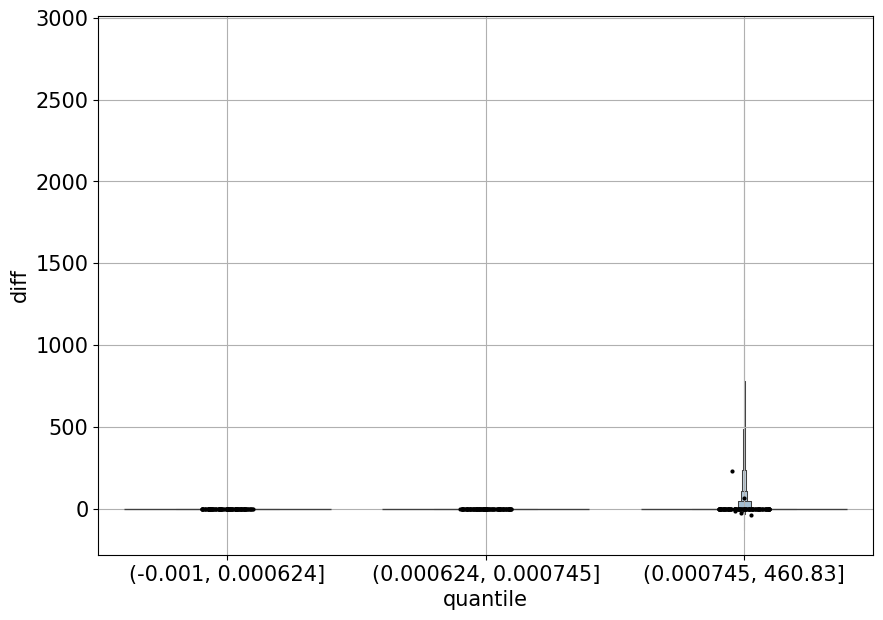

In [ ]:
y_val_diff = df.real/10**6 - df.result

nq = 3
quantile_of_price = pd.qcut(df.result, q=nq)

t = pd.DataFrame({'diff': y_val_diff, 'class': quantile_of_price})

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxenplot(t, x='class', y='diff', showfliers=False)

dots = t.groupby('class', sort=False).sample(100)
sns.stripplot(dots, x='class', y='diff', color='black', dodge=True, size=3)
plt.grid(True)
plt.xlabel('quantile', fontsize=15)
plt.ylabel('diff', fontsize=15)
plt.gca().tick_params('both', labelsize=15)
plt.gcf().set_size_inches(10, 7)

На графике ниже видно, что задача классификации достаточно неплохо разделяет 2 класса. Причем есть значение вероятности, выше которого почти нет класса 0.
Напомню, что 0 - это клиент не вернется в тестовом окне, если он был в тренировочном окне. А 1 - вернется.
Так как мы знаем, что модель гораздо чаще не добирает значения итогового ответа, то появляется гипотеза - просто увеличить вероятность, начиная с некоторого значения. Например, если вероятность возвращения 0.2 и выше, то мы заменим ее на 0.4(цифры взяты для примера) и таким образом завысим итоговые ответы и улучшим скор или даже еще проще - сдвинем все вероятности на константу и завысим итоговый предикт.

<Axes: xlabel='is_returned', ylabel='proba'>

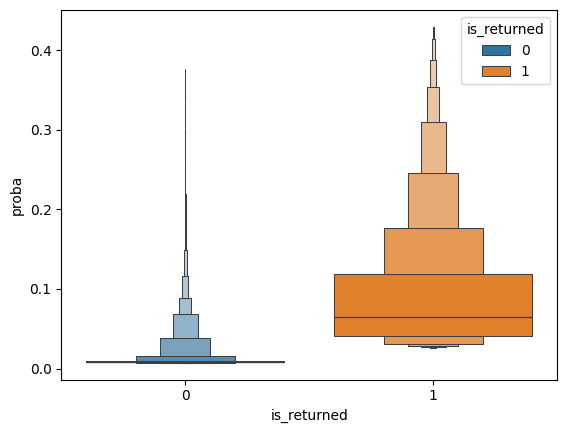

In [ ]:
prob_distrib = pd.DataFrame(index=valid_all.index)
prob_distrib['is_returned'] = valid_all['is_returned']
prob_distrib['proba'] = predict_prob


sns.boxenplot(prob_distrib, x='is_returned', y='proba', hue='is_returned', order=['0', '1'], showfliers=False)

In [ ]:
from sklearn.metrics import roc_auc_score

print("roc_auc_score задачи классификации:", roc_auc_score(valid_all['is_returned'].values, predict_prob))


roc_auc_score задачи классификации: 0.9645326681947652


Действительно, если мы просто сдвинем все вероятности на 0.1, это улучшит метрику на валидации, но на итоговом sample submission это не сработало. Думаю, что возможно это локальная особенность текущего периода данных. Если бы данных было больше, можно было бы провести анализ на разных участках.
Я также пробовал сдвигать не все вероятности,а с определенной степени уверенности. Например, выше 0.2 - это тоже не сработало на sample submission

In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob, shift_proba=0.1)

In [ ]:
print('The msle of prediction is:', round(mean_squared_log_error(df.result, df.real/10**6), 5))

The msle of prediction is: 0.12009


Как альтернатива этому действию - можно повысить вероятности, если включить флаг - дисбаланса классов. Но это явно работает хуже в такой простой постановке, что показано ниже.

In [ ]:
outliers = get_outliers(train_all)
train_all_no_otliers = train_all.drop(outliers)

X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(train_all_no_otliers, valid_all, only_returned=False)


lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
lgb_tr_ret = lgb.Dataset(X_ret, y_ret/10**6, free_raw_data=False)

params_classification = {
    'objective': 'binary',
    'verbosity': 1,
    'num_threads': 32,
    'num_leaves': 15,
    'learning_rate':0.01,
    'bagging_fraction': 0.9,
    'feature_fraction': 0.8,
    'bagging_freq':1,
    'min_data':1,
    'is_unbalance': True,


}

model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
predict_prob = model_classification.predict(X_valid)
model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=1500)
predict_regression = model_regression.predict(X_valid_ret)

Identified lowest outliers: 11
Identified upper outliers: 21
Identified outliers: 32
[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018567 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4671
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021956 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4686
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] Start training from score 1.889498


In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob)

In [ ]:
print('The msle of prediction is:', round(mean_squared_log_error(df.result, df.real/10**6), 5))

The msle of prediction is: 0.14945


Посмотрим на самые значимые фичи для модели регрессии и классификации.

Суммы денег больше зависят от количества просмотренных страниц, нажатий, страны и канала. ЧТо логично: скорее всего чем больше нажатий и просмотра страниц, тем больше продуктов мог посмотреть и купить человек.

Вероятность возвращения в тестовом периоде больше зависит от временных переменных: время от начала периода, время до конца периода, а также от количества визитов.

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

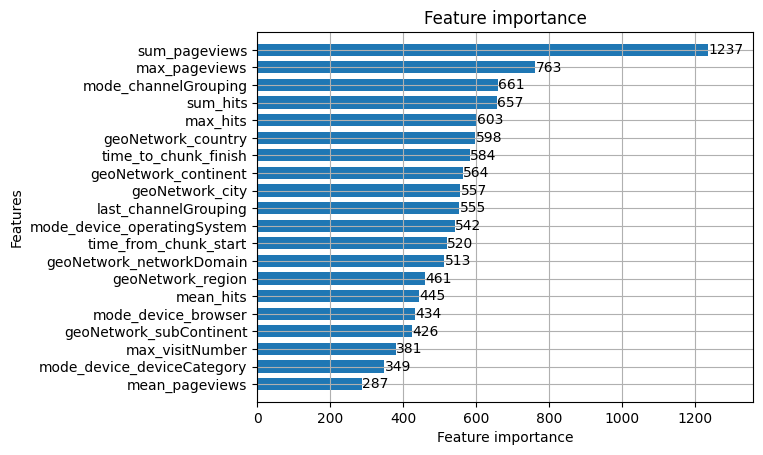

In [ ]:
lgb.plot_importance(model_regression, height=0.7, ignore_zero=True, max_num_features=20)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

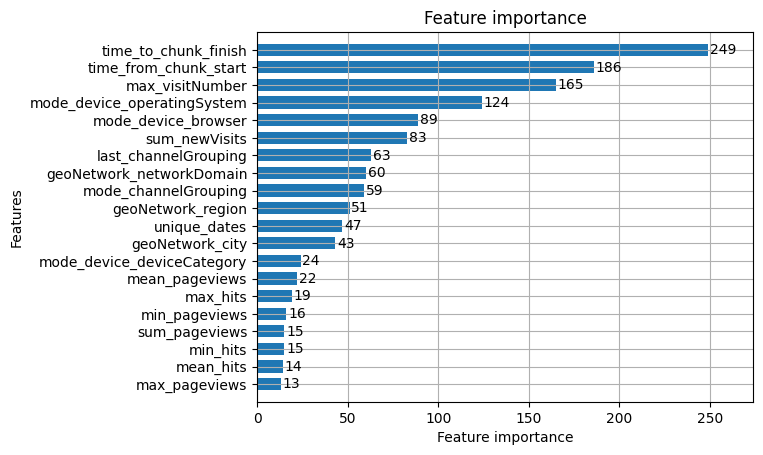

In [ ]:
lgb.plot_importance(model_classification, height=0.7, ignore_zero=True, max_num_features=20)

Если посмотреть распределения некоторых фичей для для предсказаний с большим отклонением от таргета в сторону недобора итогового значения и для всех остальных, то видно, что первые смещены. Чаще всего для больших отклонений числовые переменные имеют большие значения. Для примера возьмем фичи из топа влияния для задачи регрессии. Отсюда гипотеза - что мы можем отобрать кейсы с экстремально большими значениями sum_hits, sum_pageviews и искуственно завысить для них предсказание.

Вывод: гипотеза не подтвердилась, после отбора таких кейсов и завышения предикта - результат ухудшается и на валидации и на отложенной выборке.

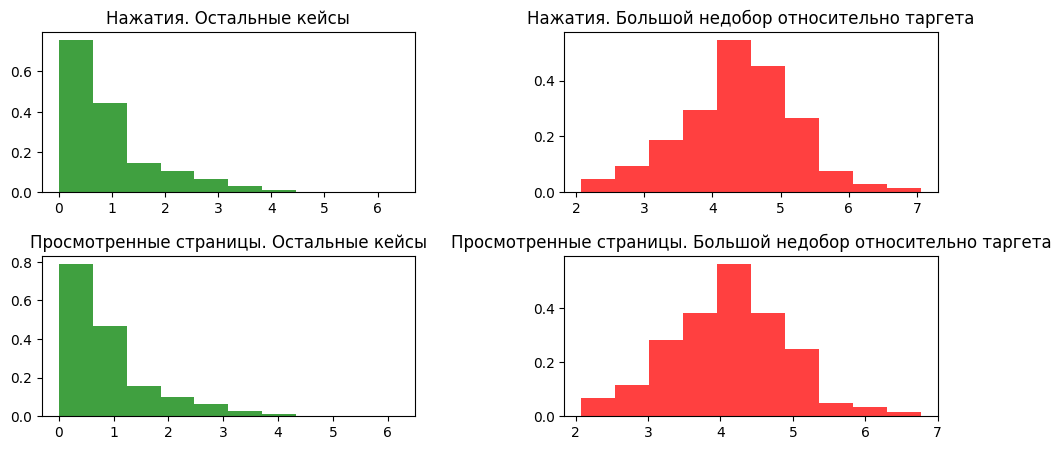

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2)



axs[0, 0].hist(np.log(X_valid.loc[y_val_diff[y_val_diff<500].index].sum_hits), density=True, histtype='stepfilled', facecolor='g',
               alpha=0.75)

axs[0, 0].set_title('Нажатия. Остальные кейсы')

axs[0, 1].hist(np.log(X_valid.loc[y_val_diff[y_val_diff>500].index].sum_hits), density=True, histtype='stepfilled', facecolor='r',
               alpha=0.75)
axs[0, 1].set_title('Нажатия. Большой недобор относительно таргета')

axs[1, 0].hist(np.log(X_valid.loc[y_val_diff[y_val_diff<500].index].sum_pageviews), density=True, histtype='stepfilled', facecolor='g',
               alpha=0.75)

axs[1, 0].set_title('Просмотренные страницы. Остальные кейсы')

axs[1, 1].hist(np.log(X_valid.loc[y_val_diff[y_val_diff>500].index].sum_pageviews), density=True, histtype='stepfilled', facecolor='r',
               alpha=0.75)
axs[1, 1].set_title('Просмотренные страницы. Большой недобор относительно таргета')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=1.5,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
plt.show()

In [ ]:
big_sum_pageviews = X_valid[X_valid.sum_pageviews>np.exp(5)].index

big_sum_hits = X_valid[X_valid.sum_hits>np.exp(5)].index



In [ ]:
df_new = df.copy()
df_new.loc[list(set(big_sum_pageviews).intersection(set(big_sum_hits))), "result"] += 500

In [ ]:
print('Old model msle:', round(mean_squared_log_error(df.result, df.real/10**6), 5))

Old model msle: 0.12918


In [ ]:
print('New model msle:', round(mean_squared_log_error(df_new.result, df_new.real/10**6), 5))

New model msle: 0.13294


В итоговом пайплайне и во всех моделях - я использую очистку от выбросов. Это улучшает итоговый скор и на валидации и на отложенной выборке. За выбросы берутся примеры, когда  логарифм sum_transactionRevenue выходит за 3 сигмы в любую сторону. Логарифмирование проводится для приведения распределения к относительно колоколообразному виду. Расчет трешхолдов для выбросов можно посмотреть в general_tools.get_outliers

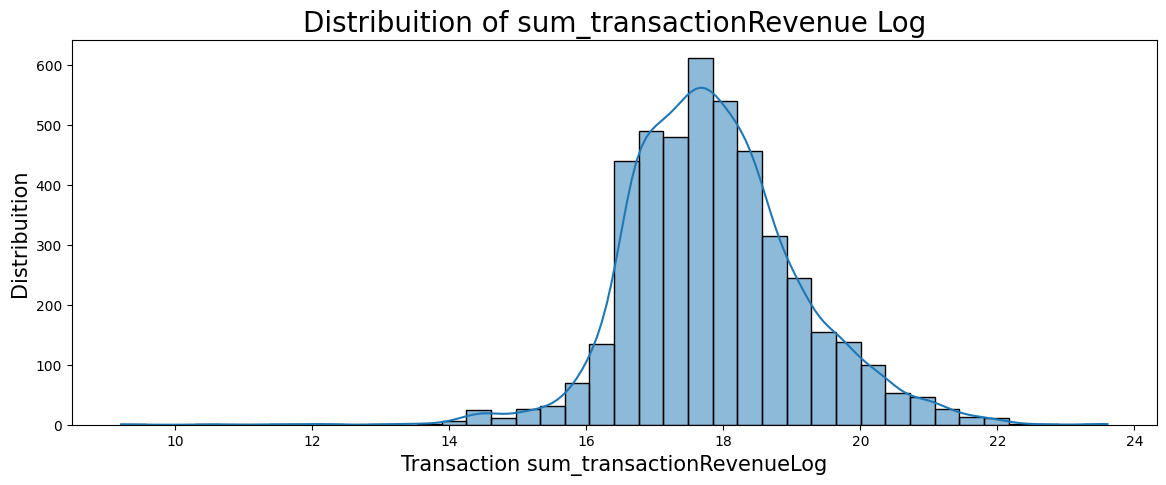

In [ ]:
plt.figure(figsize=(14,5))

ax = sns.histplot(np.log(train_all[train_all['sum_transactionRevenue'] > 0]["sum_transactionRevenue"]), bins=40, kde=True)
ax.set_xlabel('Transaction sum_transactionRevenueLog', fontsize=15) #seting the xlabel and size of font
ax.set_ylabel('Distribuition', fontsize=15) #seting the ylabel and size of font
ax.set_title("Distribuition of sum_transactionRevenue Log", fontsize=20) #seting the title and size of font

plt.show()

Также я рассмотрел подход, когда задача регрессия считается только для вернувшихся пользователей на тесте(что-то похожее делается у первого места в оригинальном контесте). Но результат не очень хороший, потому что на самом деле мы не знаем для отложенной выборки заранее какие клиенты останутся.

В коде это определяется флагом only_returned

In [ ]:
visitor_aggs_train, visitor_aggs_valid, visitor_aggs_test = get_visitor_aggs('C:/Users/egoro/ml_kaggle', from_cache=True, cat_encoding="label")

train_all = visitor_aggs_train.drop(['order'], axis=1)
valid_all = visitor_aggs_valid.drop(['order'], axis=1)

outliers = get_outliers(train_all)
train_all_no_otliers = train_all.drop(outliers)

X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(train_all_no_otliers, valid_all, only_returned=True)

lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
lgb_tr_ret = lgb.Dataset(X_ret, y_ret/10**6, free_raw_data=False)


model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
predict_prob = model_classification.predict(X_valid)
model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=300)
predict_regression = model_regression.predict(X_valid_ret)

Identified lowest outliers: 11
Identified upper outliers: 21
Identified outliers: 32
[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2693
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1938
[LightGBM] [Info] Number of data points in the train set: 4380, number of used features: 26
[LightGBM] [Info] Start training from score 19.086390


In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob)

In [ ]:
print('The amsle of prediction is:', round(score_f(df.result, df.real/10**6), 5))

The amsle of prediction is: 0.17298


# Работа с целевой метрикой (5 баллов)

Попробовал добавить кастомную метрику из контеста в качестве objective. На валидации результат неплохой, но на sample_sabmission хуже. Возможно не до конца верно прописал что-то

In [ ]:
def g(y_true,y_pred):
    res = np.log1p(y_true) - np.log1p(y_pred)
    mask = res > 0
    res[mask] = res[mask] * np.sqrt(1.2)
    return -2*(res)/(y_pred+1)

def h(y_true,y_pred):
    res = np.log1p(y_true) - np.log1p(y_pred)
    mask = res > 0
    res[mask] = res[mask] * np.sqrt(1.2)
    return (np.log1p(y_true) + res + 2)/(y_pred+1)**2


def custom_amsle(y_pred, train):
    y_true = train.get_label()
    return g(y_true,y_pred), h(y_true,y_pred)


def score_f(y_true, y_pred):
    res = np.log1p(y_true) - np.log1p(y_pred)
    mask = res > 0
    res = res ** 2
    res[mask] = res[mask] * 1.2
    return np.mean(res)

def amsle_score(y_pred, train):
    y_true = train.get_label()
    return 'AMSLE', score_f(y_true, y_pred), False

In [ ]:
params_regression = {
    'objective': custom_amsle,
    'verbosity': 1,
    'max_bin': 256,
    'learning_rate':0.01,
    'num_threads': 32,
    'num_leaves': 9,
    'bagging_fraction': 0.9,
    'feature_fraction': 0.7,
    'bagging_freq':1,
    'min_data':1,
    "lambda_l2": 0.09,
    "metric": "msle",

}
lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
lgb_tr_ret = lgb.Dataset(X_ret, y_ret, free_raw_data=False)


model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
predict_prob = model_classification.predict(X_valid)
model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=300)
predict_regression = model_regression.predict(X_valid_ret)

Identified lowest outliers: 11
Identified upper outliers: 21
Identified outliers: 32
[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2693
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2698
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] Using self-defined objective function


In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, predict_regression, predict_prob)

In [ ]:
print('The amsle of prediction is:', round(score_f(df.result, df.real/10**6), 5))

The amsle of prediction is: 0.13019


Последняя идея - сначала прологарифмировать таргет у регрессии, а метрику взять mse. Тут результат совсем плохой, опять же возможно из-за реализации

In [ ]:
outliers = get_outliers(train_all)
train_all_no_otliers = train_all.drop(outliers)

X, y, X_ret, y_ret, X_valid, y_valid, X_valid_ret = prepare_data_for_model(train_all_no_otliers, valid_all, only_returned=False)
params_regression = {
    'objective': 'regression',
    'verbosity': 1,
    'max_bin': 256,
    'learning_rate':0.01,
    'num_threads': 32,
    'num_leaves': 9,
    'bagging_fraction': 0.9,
    'feature_fraction': 0.7,
    'bagging_freq':1,
    'min_data':1,
    "lambda_l2": 0.09,
    "metric": "mse",

}
lgb_tr = lgb.Dataset(X, y, free_raw_data=False)
lgb_tr_ret = lgb.Dataset(X_ret, np.log1p(y_ret), free_raw_data=False)


model_classification = lgb.train(params_classification, lgb_tr, num_boost_round=100)
predict_prob = model_classification.predict(X_valid)
model_regression = lgb.train(params_regression, lgb_tr_ret, num_boost_round=1500)
predict_regression = model_regression.predict(X_valid_ret)

Identified lowest outliers: 11
Identified upper outliers: 21
Identified outliers: 32
[LightGBM] [Info] Number of positive: 4380, number of negative: 289002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2693
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014929 -> initscore=-4.189385
[LightGBM] [Info] Start training from score -4.189385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023606 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2698
[LightGBM] [Info] Number of data points in the train set: 293382, number of used features: 27
[LightGBM] [Info] Start training from score 0.267676


In [ ]:
df = prepare_final_df_one_model(X_valid, X_valid_ret, y_valid, np.expm1(predict_regression), predict_prob)

In [ ]:
print('The msle of prediction is:', round(mean_squared_log_error(df.result, df.real), 5))

The msle of prediction is: 2.38901
